In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('bikes4sale_Dataset_Final.csv')

In [ ]:
df

,Bike Name,Model Year,Price,Location,KMs Run,Color,Engine CC,No of Owners
0,Suzuki Avenis 125 Standard Edition,2022.0,"Rs. 69,000","Mumbai, Maharashtra","9,500 kms",Grey,125 cc,Single Owner
1,Royal Enfield Classic 650,NaN,"Rs. 4,05,000","Hyderabad, Telangana","1,000 kms",NaN,NaN,Single Owner
2,Royal Enfield Continental GT 650,2025.0,"Rs. 4,20,000","Hadapsar, Pune, Maharashtra","1,000 kms",NaN,650 cc,Single Owner
3,Suzuki Gixxer SF Fi,2018.0,"Rs. 65,000","Hyderabad, Telangana","16,500 kms",NaN,NaN,Two
4,Suzuki Gixxer 150,2018.0,"Rs. 60,000","KR Puram, Bangalore, Karnataka","30,000 kms",NaN,NaN,Single Owner
...,...,...,...,...,...,...,...,...
2022,Royal Enfield Classic 350 2024,2024.0,"Rs. 1,80,000","KR Puram, Bangalore, Karnataka",NaN,NaN,NaN,Single Owner
2023,Suzuki Access 125,2015.0,"Rs. 28,000","Mangalore, Karnataka","53,000 kms",NaN,NaN,Single Owner
2024,Yamaha MT-15 Ver 2.0,2023.0,"Rs. 1,50,000","Belgaum, Karnataka","9,414 kms",NaN,NaN,Single Owner
2025,Royal Enfield Himalayan,NaN,"Rs. 1,30,000","Borivali, Mumbai, Maharashtra","7,900 kms",NaN,NaN,Single Owner


# Column list and shape

In [ ]:
print("Shape:", df.shape)
print("Columns:\n", list(df.columns))

Shape: (2027, 8)
Columns:
 ['Bike Name', 'Model Year', 'Price', 'Location', 'KMs Run', 'Color', 'Engine CC', 'No of Owners']


# Check Basic Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Bike Name     2027 non-null   object 
 1   Model Year    1988 non-null   float64
 2   Price         1976 non-null   object 
 3   Location      2027 non-null   object 
 4   KMs Run       1981 non-null   object 
 5   Color         753 non-null    object 
 6   Engine CC     698 non-null    object 
 7   No of Owners  2021 non-null   object 
dtypes: float64(1), object(7)
memory usage: 126.8+ KB


In [ ]:
df.describe(include = 'all')

,Bike Name,Model Year,Price,Location,KMs Run,Color,Engine CC,No of Owners
count,2027,1988.000000,1976,2027,1981,753,698,2021
unique,629,NaN,235,540,740,273,85,4
top,Royal Enfield Classic 350,NaN,"Rs. 40,000","Bangalore, Karnataka","25,000 kms",Black,350 cc,Single Owner
freq,44,NaN,72,122,43,193,87,1927
mean,NaN,2019.268612,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,4.695808,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1980.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2023.000000,NaN,NaN,NaN,NaN,NaN,NaN


# Missing values

In [ ]:
df.isnull().sum()

Bike Name          0
Model Year        39
Price             51
Location           0
KMs Run           46
Color           1274
Engine CC       1329
No of Owners       6
dtype: int64

# Data Cleaning

## Remove Special Characters (Price & KMs & Engine CC)

In [ ]:
df["Price"] = df["Price"].str.replace("Rs.", "", regex=False)\
                          .str.replace(",", "", regex=False)
df["KMs Run"] = df["KMs Run"].str.replace("kms", "", regex=False)\
                            .str.replace(",", "", regex=False)

In [ ]:
df["Engine CC"] = df["Engine CC"].str.replace("cc", "", regex=False)

##### - Initially, numeric columns contained units and symbols, so they required preprocessing before analysis.
- Removed currency symbols and commas from Price

- Removed units like “kms” and commas from KMs Run

- Removed “cc” text from Engine CC

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Bike Name     2027 non-null   object 
 1   Model Year    1988 non-null   float64
 2   Price         1976 non-null   object 
 3   Location      2027 non-null   object 
 4   KMs Run       1981 non-null   object 
 5   Color         753 non-null    object 
 6   Engine CC     698 non-null    object 
 7   No of Owners  2021 non-null   object 
dtypes: float64(1), object(7)
memory usage: 126.8+ KB


# Convert Data Types

In [ ]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["KMs Run"] = pd.to_numeric(df["KMs Run"], errors="coerce")

df["Engine CC"] = pd.to_numeric(df["Engine CC"], errors="coerce")

- Converting Price, KMs Run, and Engine CC to numeric exposed invalid and missing values.

- Any non-numeric or empty entries were automatically converted to NaN.

- This confirms that some listings contained incomplete or inconsistent numeric information.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Bike Name     2027 non-null   object 
 1   Model Year    1988 non-null   float64
 2   Price         1976 non-null   float64
 3   Location      2027 non-null   object 
 4   KMs Run       1981 non-null   float64
 5   Color         753 non-null    object 
 6   Engine CC     698 non-null    float64
 7   No of Owners  2021 non-null   object 
dtypes: float64(4), object(4)
memory usage: 126.8+ KB


# Handle Missing Values

In [ ]:
df["Price"] = df["Price"].fillna(df["Price"].median())
df["KMs Run"] = df["KMs Run"].fillna(df["KMs Run"].median())

Missing values in Price and KMs Run are replaced with their respective median values to handle outliers effectively and ensure data consistency.

In [ ]:
df["Model Year"] = df["Model Year"].fillna(df["Model Year"].median())
df["Model Year"] = df["Model Year"].round().astype("Int64")

##### Why Median is Used Instead of Mode for Model Year

Model Year is a time-based numeric variable, not a category.

The dataset contains bikes from many different years, with no single year dominating clearly.

Mode selects only the most frequent year, which may not represent the overall data.

Using mode can bias the dataset toward one popular year.

Median represents the central year of the dataset and preserves the original year distribution.

Median is less affected by skewness or uneven frequency across years.

In [ ]:
df["No of Owners"] = df["No of Owners"].fillna(df["No of Owners"].mode()[0])

In [ ]:
df["Color"] = df["Color"].fillna("Not Mentioned")

The Color column contains a high number of missing values. Since it is a categorical feature and missing values indicate non-disclosure rather than incorrect data, the column was retained and missing values were imputed with the category ‘Not Mentioned’ instead of being dropped

In [ ]:
df["Engine CC"] = df["Engine CC"].fillna(df["Engine CC"].median())

# Standardize Text Columns

In [ ]:
df["No of Owners"] = df["No of Owners"].replace({
    "Single Owner": "One Owner",
    "Two": "Two Owners",
    "Three": "Three Owners",
    "Four" : "Four Owners"
})

The No of Owners column is standardized to “One Owner” and “Two Owners” for clarity and consistency.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Bike Name     2027 non-null   object 
 1   Model Year    2027 non-null   Int64  
 2   Price         2027 non-null   float64
 3   Location      2027 non-null   object 
 4   KMs Run       2027 non-null   float64
 5   Color         2027 non-null   object 
 6   Engine CC     2027 non-null   float64
 7   No of Owners  2027 non-null   object 
dtypes: Int64(1), float64(3), object(4)
memory usage: 128.8+ KB


# Remove Duplicates

In [ ]:
df.drop_duplicates(inplace=True)

# After Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1999 entries, 0 to 2026
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Bike Name     1999 non-null   object 
 1   Model Year    1999 non-null   Int64  
 2   Price         1999 non-null   float64
 3   Location      1999 non-null   object 
 4   KMs Run       1999 non-null   float64
 5   Color         1999 non-null   object 
 6   Engine CC     1999 non-null   float64
 7   No of Owners  1999 non-null   object 
dtypes: Int64(1), float64(3), object(4)
memory usage: 142.5+ KB


In [ ]:
df.isnull().sum()

Bike Name       0
Model Year      0
Price           0
Location        0
KMs Run         0
Color           0
Engine CC       0
No of Owners    0
dtype: int64

In [ ]:
# Split location by comma
location_split = df["Location"].str.split(",")

# Extract State (last part)
df["State"] = location_split.str[-1].str.strip()

# Keep remaining parts (everything except State) as Location
df["Location"] = location_split.str[:-1].apply(
    lambda x: ", ".join([i.strip() for i in x])
)


In [ ]:
df

,Bike Name,Model Year,Price,Location,KMs Run,Color,Engine CC,No of Owners,State
0,Suzuki Avenis 125 Standard Edition,2022,69000.0,Mumbai,9500.0,Grey,125.0,One Owner,Maharashtra
1,Royal Enfield Classic 650,2020,405000.0,Hyderabad,1000.0,Not Mentioned,161.0,One Owner,Telangana
2,Royal Enfield Continental GT 650,2025,420000.0,"Hadapsar, Pune",1000.0,Not Mentioned,650.0,One Owner,Maharashtra
3,Suzuki Gixxer SF Fi,2018,65000.0,Hyderabad,16500.0,Not Mentioned,161.0,Two Owners,Telangana
4,Suzuki Gixxer 150,2018,60000.0,"KR Puram, Bangalore",30000.0,Not Mentioned,161.0,One Owner,Karnataka
...,...,...,...,...,...,...,...,...,...
2022,Royal Enfield Classic 350 2024,2024,180000.0,"KR Puram, Bangalore",20400.0,Not Mentioned,161.0,One Owner,Karnataka
2023,Suzuki Access 125,2015,28000.0,Mangalore,53000.0,Not Mentioned,161.0,One Owner,Karnataka
2024,Yamaha MT-15 Ver 2.0,2023,150000.0,Belgaum,9414.0,Not Mentioned,161.0,One Owner,Karnataka
2025,Royal Enfield Himalayan,2020,130000.0,"Borivali, Mumbai",7900.0,Not Mentioned,161.0,One Owner,Maharashtra


# NON-VISUALIZATION

## Univariate Analysis

In [ ]:
df["No of Owners"].value_counts(normalize=True) * 100

No of Owners
One Owner       95.347674
Two Owners       3.951976
Three Owners     0.400200
Four Owners      0.300150
Name: proportion, dtype: float64

##### Majority of bikes are single-owner vehicles.

In [ ]:
df["State"].value_counts().head(10)

State
Maharashtra      519
Karnataka        356
Tamil Nadu       228
Telangana        189
Uttar Pradesh    144
Delhi             88
Gujarat           79
West Bengal       73
Haryana           65
Kerala            42
Name: count, dtype: int64

##### Karnataka and Maharashtra have the highest number of listings.

## Bivariate Analysis

In [ ]:
df[["Price", "KMs Run", "Model Year", "Engine CC"]].corr()

,Price,KMs Run,Model Year,Engine CC
Price,1.000000,-0.048844,0.363126,0.339551
KMs Run,-0.048844,1.000000,-0.066639,-0.019942
Model Year,0.363126,-0.066639,1.000000,0.020965
Engine CC,0.339551,-0.019942,0.020965,1.000000


- Price has a positive correlation with model year and engine capacity, indicating that newer and higher-capacity bikes tend to be priced higher. Price shows a weak negative correlation with kilometers run, suggesting that higher usage slightly reduces the price.

In [ ]:
df.groupby("Model Year")["Price"].median()

Model Year
1980    177500.0
1986    150000.0
1993     40000.0
1995     80000.0
1997      6000.0
1998     80000.0
1999    175000.0
2000     90000.0
2003    120000.0
2005     17500.0
2006      7000.0
2007     22500.0
2008     15000.0
2009     20000.0
2010     25000.0
2011     25000.0
2012     30000.0
2013     35000.0
2014     40000.0
2015     42000.0
2016     45000.0
2017     52400.0
2018     63000.0
2019     72000.0
2020     80000.0
2021    100000.0
2022    100000.0
2023    120000.0
2024    120000.0
2025    150000.0
2026      9000.0
Name: Price, dtype: float64

- Median price analysis shows that older bikes have highly variable prices due to rarity and condition, while recent bikes (2016–2025) show a clear upward trend in median prices, reflecting the market value of modern models. Using median instead of mean reduces the impact of extreme outliers and provides a more realistic view of typical bike prices for each year.

In [ ]:
df.groupby("State")["KMs Run"].agg(["count", "median"]).sort_values(by="median", ascending=False)

,count,median
State,,
Goa,5,60000.0
Jammu Kashmir,2,31500.0
Orissa,27,31000.0
Bihar,13,30000.0
Gujarat,79,27600.0
Chhattisgarh,3,25000.0
Dadra Nagar Haveli,1,23400.0
Kerala,42,23121.0
Tamil Nadu,228,23000.0


- Median kilometers run varies by state, highlighting regional differences in bike usage, condition, and resale potential.

## Multivariate Analysis

In [ ]:
df.groupby(["State", "No of Owners"])["Price"].median().unstack()

No of Owners,Four Owners,One Owner,Three Owners,Two Owners
State,,,,
Andhra Pradesh,NaN,92500.0,NaN,NaN
Arunachal Pradesh,NaN,134000.0,NaN,NaN
Assam,NaN,167500.0,NaN,NaN
Bihar,NaN,52500.0,NaN,62000.0
Chandigarh,NaN,150000.0,NaN,NaN
Chhattisgarh,NaN,80000.0,NaN,NaN
Dadra Nagar Haveli,NaN,45000.0,NaN,NaN
Delhi,NaN,75000.0,25000.0,37000.0
Goa,NaN,49000.0,NaN,NaN


- Median bike prices vary across states and ownership categories, showing that single-owner bikes generally have higher prices while multi-owner bikes are priced lower.
- NaN values indicate the absence of listings for certain state–owner combinations rather than missing or incorrect data.

# VISUALIZATION

## UNIVARIATE ANALYSIS

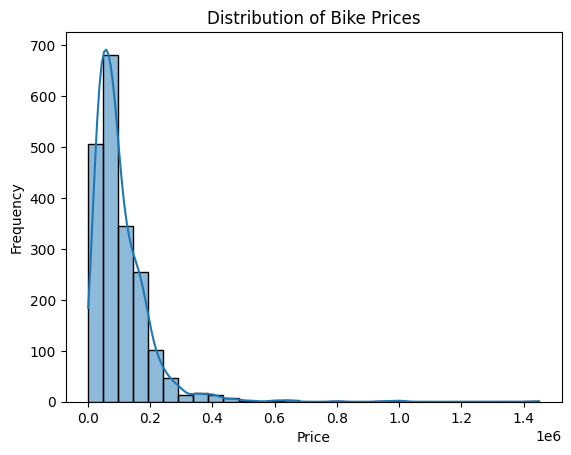

In [ ]:
sns.histplot(df["Price"],bins = 30,kde = True)
plt.title("Distribution of Bike Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

The histogram shows that most bikes are priced below ₹2 lakh, with a few expensive bikes creating a long right tail, indicating a right-skewed distribution.

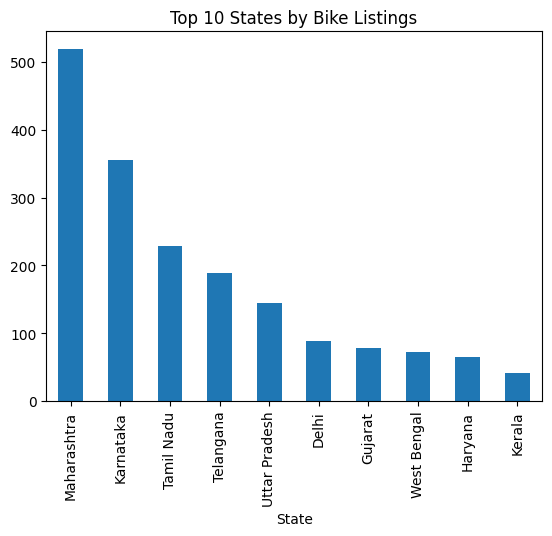

In [ ]:
df["State"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 States by Bike Listings")
plt.show()

The bar chart shows that Maharashtra has the highest number of bike listings, followed by Karnataka and Tamil Nadu.
This indicates that bike listings are concentrated in a few major states, while other states have comparatively fewer listings.

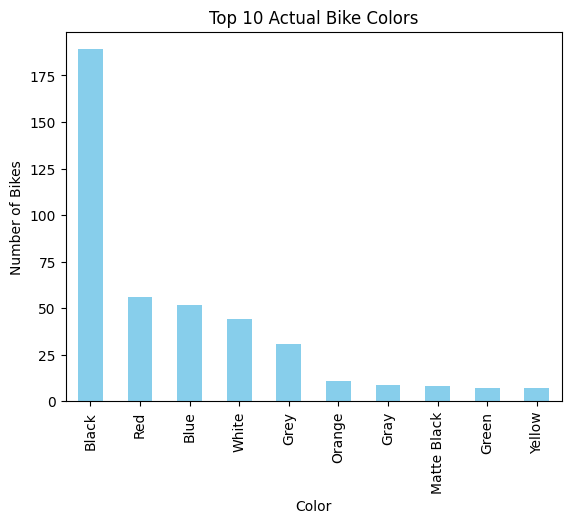

In [ ]:
color_counts = df[df["Color"] != "Not Mentioned"]["Color"].value_counts().head(10)
color_counts.plot(kind="bar", color='skyblue')
plt.title("Top 10 Actual Bike Colors")
plt.xlabel("Color")
plt.ylabel("Number of Bikes")
plt.show()

- Black is the most frequently listed color.
- Red, Blue, and White are moderately common.
- Other colors like Grey, Orange, Green, and Yellow are less common.
- Analysis excludes bikes where color is not mentioned.

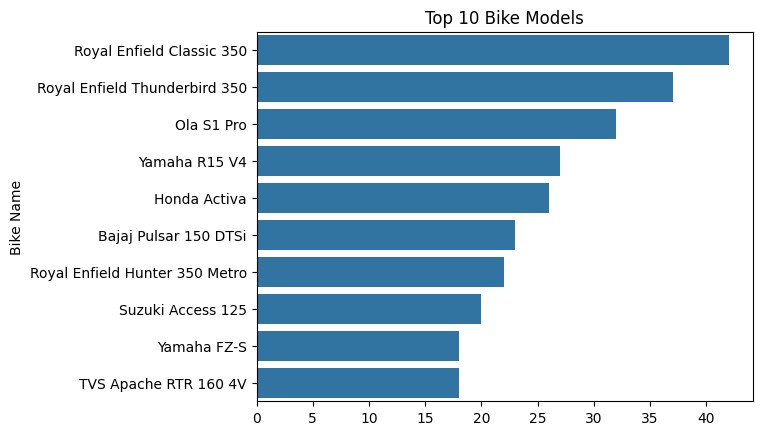

In [ ]:
top_bikes = df["Bike Name"].value_counts().head(10)
plt.figure()
sns.barplot(x=top_bikes.values, y=top_bikes.index)
plt.title("Top 10 Bike Models")
plt.show()

Royal Enfield Classic 350 appears most frequently, followed by other popular models, showing these are the most listed and likely most sold bikes in the market.

## BIVARIATE ANALYSIS

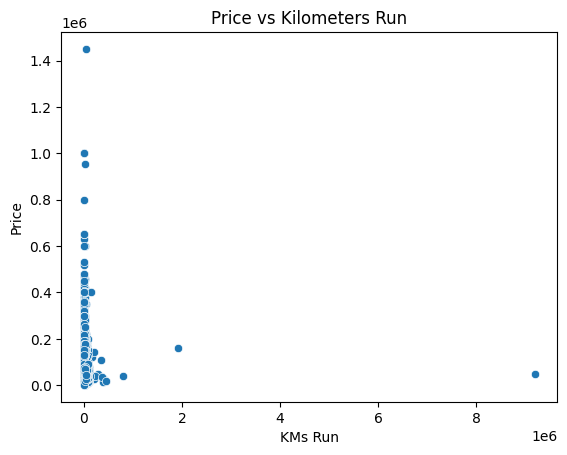

In [ ]:
sns.scatterplot(x="KMs Run", y="Price", data=df)
plt.title("Price vs Kilometers Run")
plt.show()

There is a negative (inverse) relationship between kilometers run and price.
Bikes with lower mileage tend to have higher prices, while prices decrease as kilometers increase, with a few noticeable outliers.

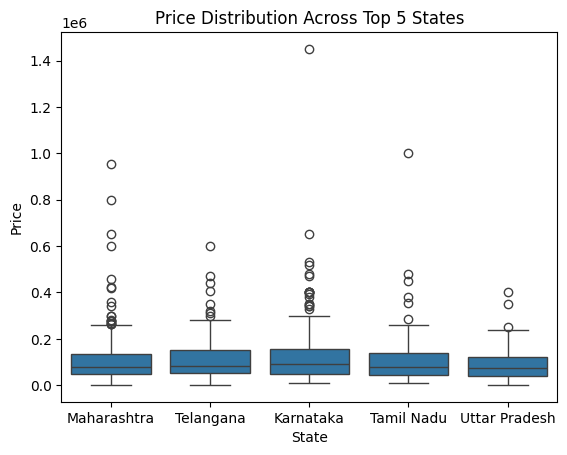

In [ ]:
top_states = df["State"].value_counts().head(5).index
sns.boxplot(x="State", y="Price", data=df[df["State"].isin(top_states)])
plt.title("Price Distribution Across Top 5 States")
plt.show()

The box plot indicates that bike prices are unevenly distributed across states, with noticeable differences in spread.
States like Karnataka show wider price ranges and extreme outliers, while others have more compact distributions around the median.

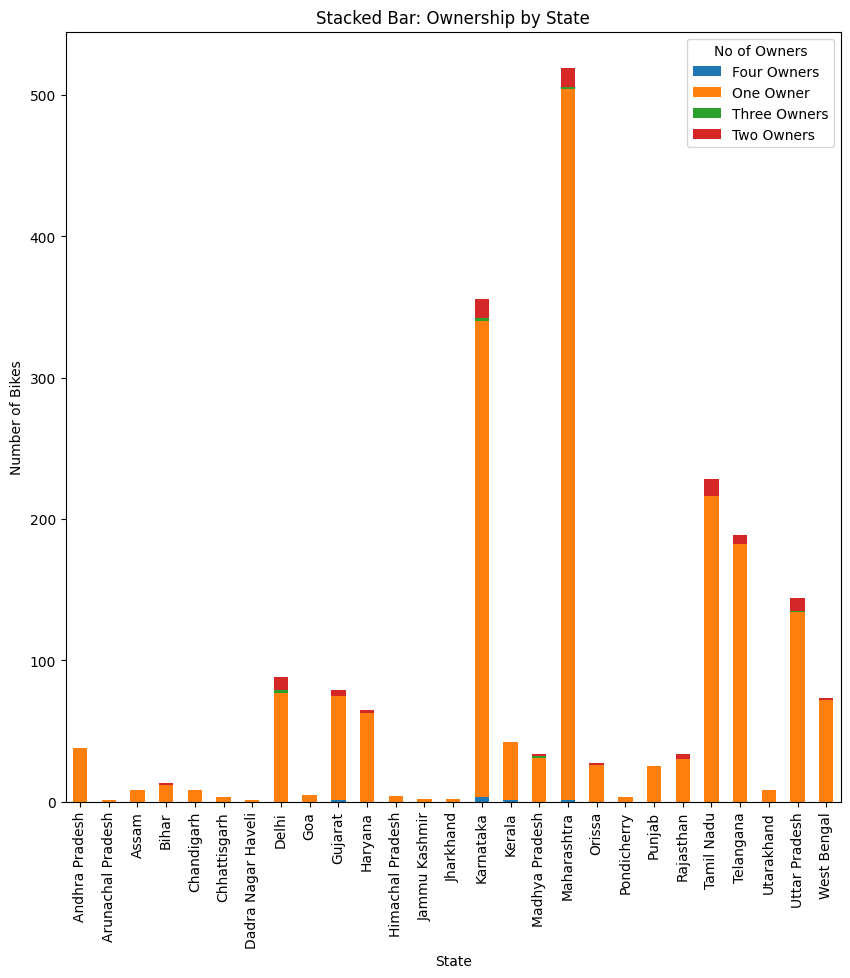

In [ ]:
ct = pd.crosstab(df["State"], df["No of Owners"])
ct.plot(kind="bar", stacked=True, figsize=(10,10))
plt.title("Stacked Bar: Ownership by State")
plt.xlabel("State")
plt.ylabel("Number of Bikes")
plt.show()


The chart shows that one-owner bikes dominate across all states, indicating a strong preference for first-time ownership.
States like Maharashtra, Karnataka, and Tamil Nadu have the highest bike counts, while multi-owner bikes are minimal, showing low resale frequency.

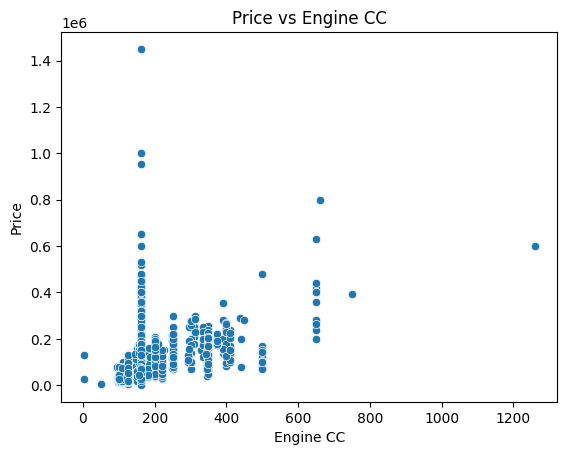

In [ ]:
sns.scatterplot(x="Engine CC", y="Price", data=df)
plt.title("Price vs Engine CC")
plt.show()

The scatter plot shows a positive relationship between engine CC and price, where bikes with higher engine capacity generally have higher prices.
However, there is considerable spread and some outliers, indicating that price is also influenced by other factors such as brand, model year, and condition.

## MULTIVARIATE ANALYSIS

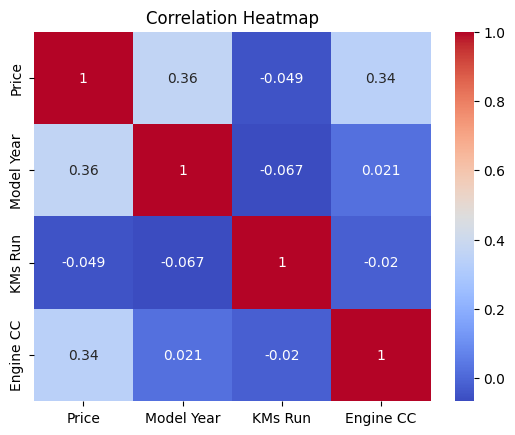

In [ ]:
sns.heatmap(
    df[["Price", "Model Year", "KMs Run", "Engine CC"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows a moderate positive correlation of price with model year (0.36) and engine CC (0.34), indicating newer and higher-capacity bikes tend to cost more.
Kilometers run has a weak negative correlation with price, suggesting mileage has only a small impact compared to other factors.